## Scikit-learn Pipelines & Tuned Mini-Project

In [133]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score
from sklearn.model_selection import cross_val_score

In [115]:
df = pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition.csv")

df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [116]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

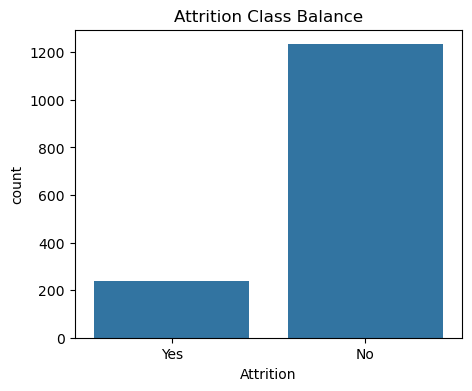

In [117]:
plt.figure(figsize=(5,4))
sns.countplot(data=df, x="Attrition")
plt.title("Attrition Class Balance")
plt.show()

Here we can see that most of the employees stayed at the company (No),
while only a small portion left (Yes). This confirms the dataset is
imbalanced, so we will need techniques like stratified cross-validation
and class_weight='balanced' when training the model.

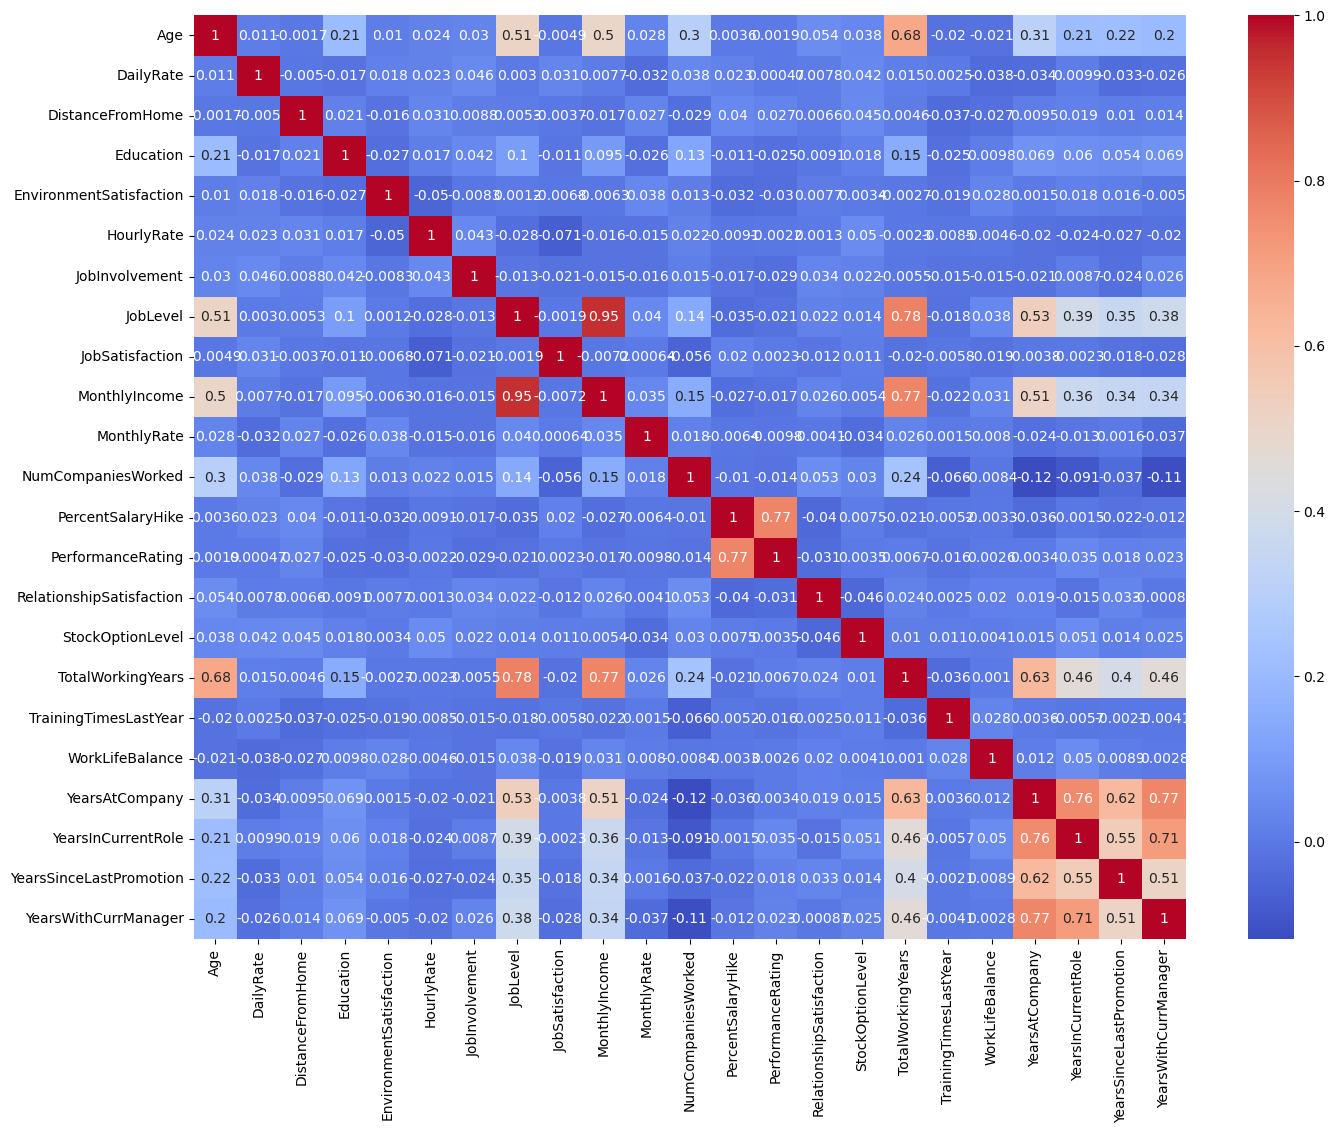

In [118]:
cols_to_drop = ["EmployeeCount", "StandardHours", "EmployeeNumber"]
df_numeric = df.drop(columns=cols_to_drop, errors="ignore")
corr = df_numeric.corr(numeric_only=True)
plt.figure(figsize=(16, 12))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.show()

This heatmap shows how numeric features relate to each other. Strong
correlations (dark red or dark blue) mean two features carry similar
information. We should watch for very high correlations, since they
can cause redundancy in the model.

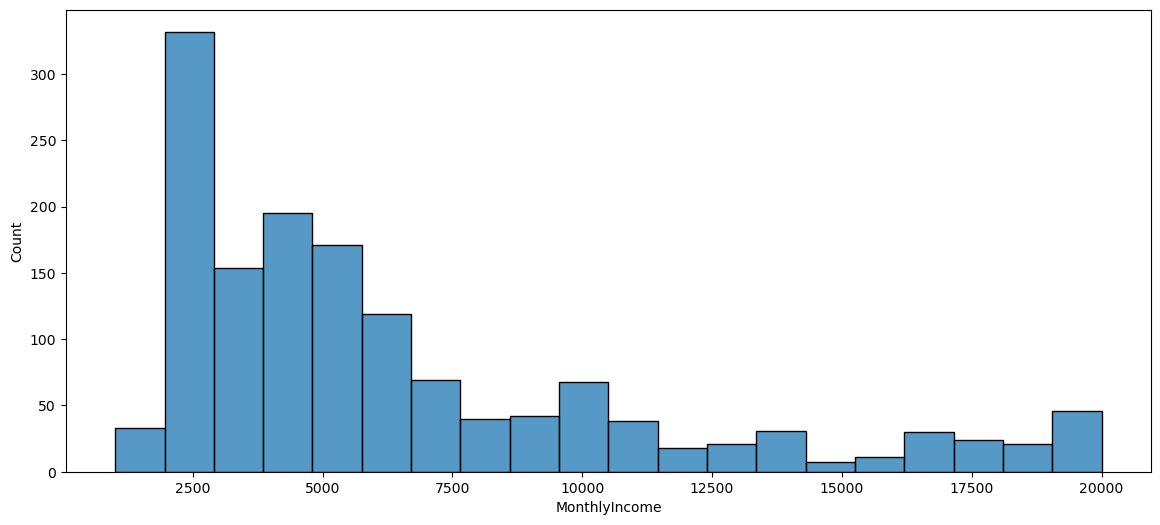

In [119]:
plt.figure(figsize=(14,6))
sns.histplot(data=df, x ="MonthlyIncome" )
plt.show()

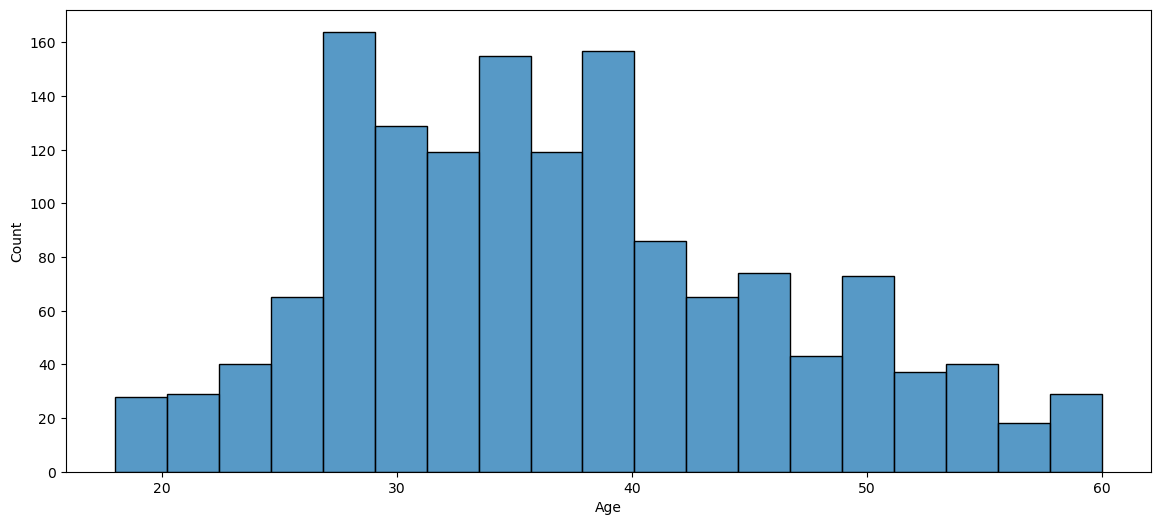

In [120]:
plt.figure(figsize=(14,6))
sns.histplot(data=df, x ="Age" )
plt.show()

we can see that most of people earn around ~2500-500 monthly. Age is
closer to a normal distribution, centered around the 30-40.

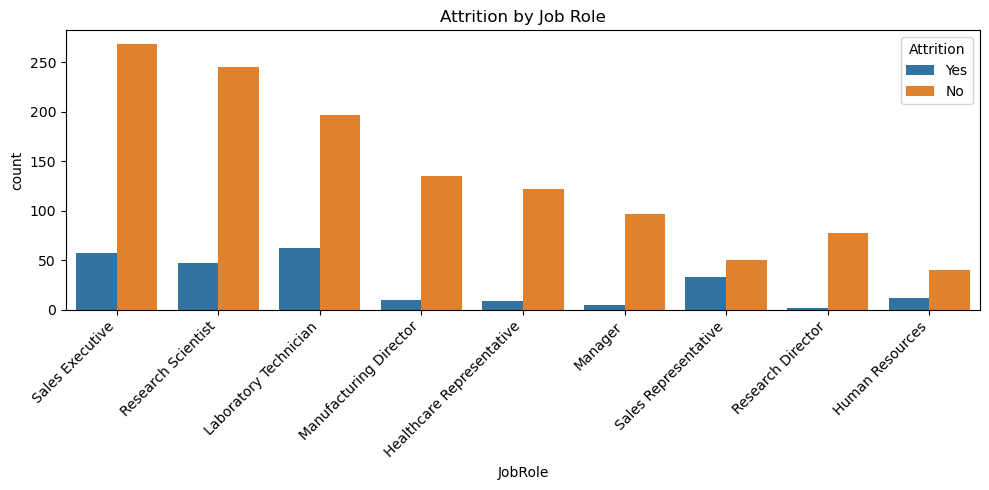

In [121]:
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x="JobRole", hue="Attrition")
plt.title("Attrition by Job Role")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

Attrition varies noticeably across job roles. Sales Representative
stands out with a very high attrition rate — nearly half of employees
in this role left. Roles with more employees, like Laboratory Technician,
show a higher raw count of attrition but a lower rate. This shows why
comparing rates (not just counts) is important for smaller groups.

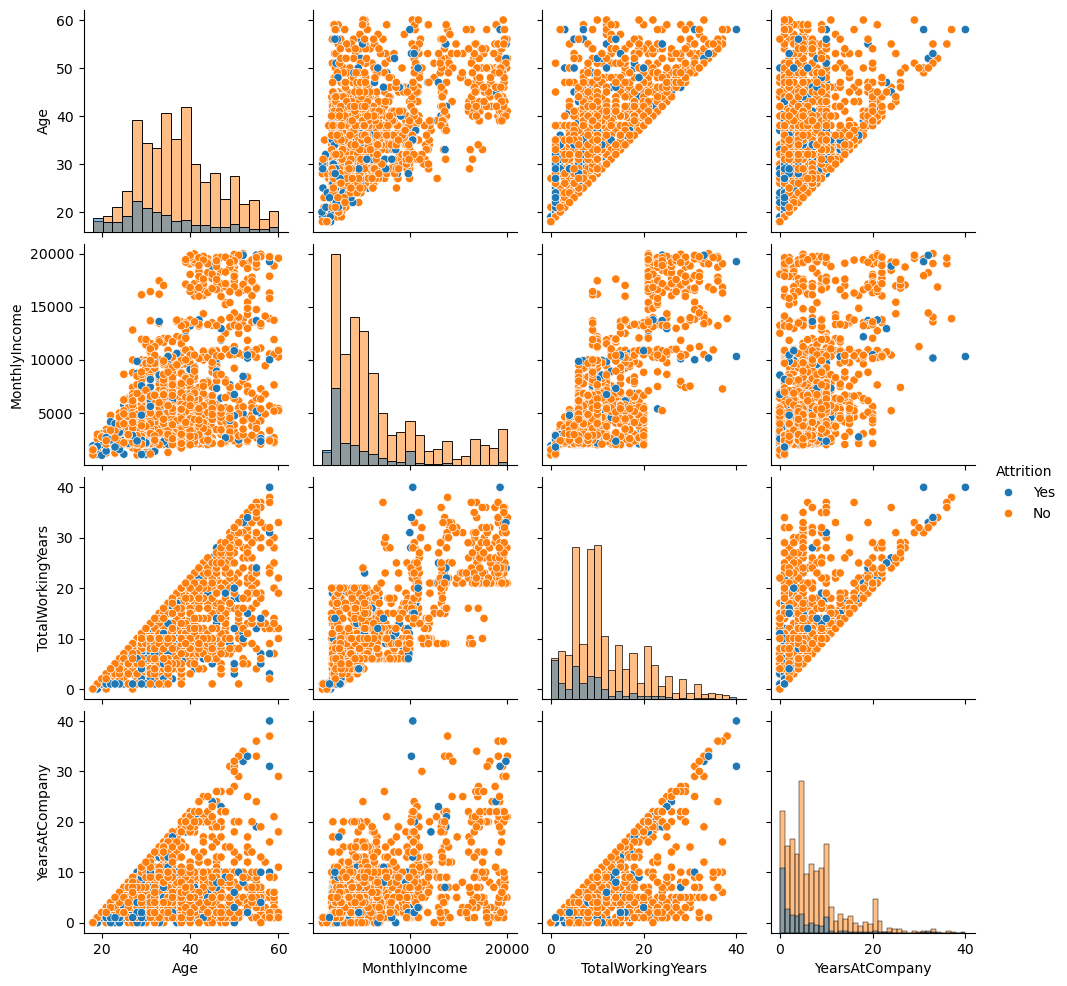

In [122]:
cols = ["Age", "MonthlyIncome", "TotalWorkingYears", "YearsAtCompany", "Attrition"]

sns.pairplot(df[cols], hue="Attrition", diag_kind="hist", palette="tab10")
plt.show()

This pairplot compares Age, MonthlyIncome, TotalWorkingYears, and
YearsAtCompany together, colored by Attrition. Employees who left
(orange) tend to cluster toward younger age, lower income, and fewer
working years, while employees who stayed (blue) are more spread out
across older ages and higher income. This suggests these features
combined carry useful signal for predicting attrition.

In [123]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [124]:
df = df.drop(columns=["EmployeeCount", "StandardHours", "Over18", "EmployeeNumber"])

## Step 2: Add the engineered features from Day 4 into the workflow. ##

IncomePerYearWorked captures whether an employee is underpaid relative
to their experience — low values may indicate dissatisfaction.
PromotionGapRatio shows how large a share of an employee's tenure has
passed without a promotion, which could signal frustration and higher
attrition risk.

In [125]:
df["Attrition"] = df["Attrition"].map({"No": 0, "Yes": 1})

In [126]:
numeric_cols = []
num = 66
categorical_cols = []
for feature in df.columns:
    if type(num) == df[feature].dtype:
        numeric_cols.append(feature)
    else:
        categorical_cols.append(feature)

print(numeric_cols)
print(categorical_cols)

['Age', 'Attrition', 'DailyRate', 'DistanceFromHome', 'Education', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']
['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']


In [127]:
df["IncomePerYearWorked"] = df["MonthlyIncome"] / (df["TotalWorkingYears"] + 1)
df["PromotionGapRatio"] = df["YearsSinceLastPromotion"] / (df["YearsAtCompany"] + 1)
df["AgeStartedWorking"] = df["Age"] - df["TotalWorkingYears"]

numeric_cols.append("IncomePerYearWorked")
numeric_cols.append("PromotionGapRatio")
numeric_cols.append("AgeStartedWorking")

In [128]:
numeric_cols.remove("Attrition")

In [129]:
print(numeric_cols)
print(categorical_cols)

['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager', 'IncomePerYearWorked', 'PromotionGapRatio', 'AgeStartedWorking']
['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']


In [130]:
X = df.drop(columns=["Attrition"])
y = df["Attrition"]

In [131]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

## Step 1: Build a Pipeline with a ColumnTransformer handling numeric (scaling) and categorical (encoding) columns. ##

In [138]:
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numeric_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
])

pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(class_weight="balanced", max_iter=1000)),
])

## Step 3: Tune the full pipeline with GridSearchCV and 5-fold cross-validation. ##

In [141]:
from sklearn.model_selection import cross_val_score

baseline_scores = cross_val_score(pipe, X_train, y_train, cv=5, scoring="f1")
print("Baseline CV F1 mean:", baseline_scores.mean())
print("Baseline CV F1 std:", baseline_scores.std())

Baseline CV F1 mean: 0.5064321436700717
Baseline CV F1 std: 0.06614583870050292


In [142]:
from sklearn.model_selection import GridSearchCV

param_grid = {"model__C": [0.01, 0.1, 1, 10, 100]}

grid = GridSearchCV(pipe, param_grid, cv=5, scoring="f1")
grid.fit(X_train, y_train)

print("Best params:", grid.best_params_)
print("Best CV F1:", grid.best_score_)

Best params: {'model__C': 0.1}
Best CV F1: 0.5066462582174964


## Step 4: Evaluate the final tuned pipeline once on the held-out test set and report the metric against a baseline. ##

In [143]:
from sklearn.metrics import f1_score, classification_report

best_model = grid.best_estimator_
y_pred = best_model.predict(X_test)

print("Test F1:", f1_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Test F1: 0.49612403100775193
              precision    recall  f1-score   support

           0       0.93      0.80      0.86       247
           1       0.39      0.68      0.50        47

    accuracy                           0.78       294
   macro avg       0.66      0.74      0.68       294
weighted avg       0.84      0.78      0.80       294



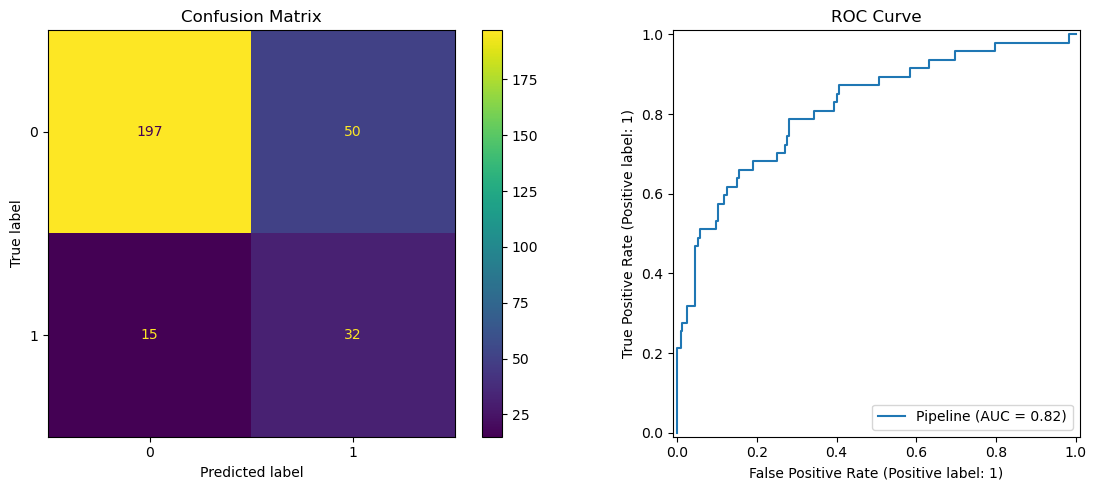

In [144]:
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay.from_estimator(best_model, X_test, y_test, ax=axes[0])
axes[0].set_title("Confusion Matrix")

RocCurveDisplay.from_estimator(best_model, X_test, y_test, ax=axes[1])
axes[1].set_title("ROC Curve")

plt.tight_layout()
plt.show()

The confusion matrix shows the model correctly identifies 32 out of 47
employees who actually left (recall ~68%), while producing 50 false
positives. The ROC curve gives an AUC of 0.82, indicating the model
separates the two classes reasonably well overall, better than the F1
score alone suggests, since F1 is sensitive to the classification
threshold and the small size of the positive class.